In [1]:
# Import necessary libraries for data analysis and visualization
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# Ensure the results/plots folder exists
os.makedirs("results/plots", exist_ok=True)

In [3]:
# Load datasets from CSV files
df_lifestyle = pd.read_csv("data/student_lifestyle_dataset.csv")
df_realnames = pd.read_csv("data/us_dataset_real_names.csv")

In [4]:
# Remove duplicate rows from both datasets
df_lifestyle = df_lifestyle.drop_duplicates()
df_realnames = df_realnames.drop_duplicates()

In [5]:
# Data cleaning and preprocessing for student lifestyle dataset
# Convert relevant columns to numeric format to handle invalid or missing values
df_lifestyle["Sleep_Hours_Per_Day"] = pd.to_numeric(df_lifestyle["Sleep_Hours_Per_Day"], errors="coerce")
df_lifestyle["Social_Hours_Per_Day"] = pd.to_numeric(df_lifestyle["Social_Hours_Per_Day"], errors="coerce")

# Define stress levels as ordered categories: Low < Moderate < High
# This maintains logical ordering and prevents incorrect comparisons
stress_order = pd.CategoricalDtype(categories = ["Low", "Moderate", "High"], ordered = True)
df_lifestyle["Stress_Level"] = df_lifestyle["Stress_Level"].astype(stress_order)
df_lifestyle["Stress_Level_Numeric"] = df_lifestyle["Stress_Level"].cat.codes

# Handle invalid GPA values (outside range [0, 4])
# Replace out-of-range GPA with the mean of valid GPA values
valid_gpa_mask = (df_lifestyle["GPA"] >= 0) & (df_lifestyle["GPA"] <= 4)
mean_gpa = df_lifestyle.loc[valid_gpa_mask, "GPA"].mean().round(2)
df_lifestyle.loc[~valid_gpa_mask, "GPA"] = mean_gpa

# Identify all columns representing hours per day (Sleep_Hours_Per_Day, Social_Hours_Per_Day, etc.)
hour_cols = [col for col in df_lifestyle.columns if "Hours_Per_Day" in col]

# Clean invalid hour values (NaN, negative, or > 24)
# Distribute remaining time in the day equally among invalid entries
bad_mask = (df_lifestyle[hour_cols].isna()) | (df_lifestyle[hour_cols] < 0) | (df_lifestyle[hour_cols] > 24)
valid_sums = df_lifestyle[hour_cols].where(~bad_mask, 0).sum(axis=1)
remaining_time = (24 - valid_sums).clip(lower=0)
bad_counts = bad_mask.sum(axis=1)
fill_values = remaining_time.div(bad_counts).replace([np.inf, -np.inf], 0)
df_lifestyle[hour_cols] = df_lifestyle[hour_cols].mask(bad_mask, fill_values, axis=0)

In [6]:
# Convert columns in the real names dataset to appropriate data types
# String types for names and categorical type for city to optimize memory usage
df_realnames["first_name"] = df_realnames["first_name"].astype(str)
df_realnames["last_name"] = df_realnames["last_name"].astype(str)
df_realnames["city"] = df_realnames["city"].astype("category")

In [7]:
# Merge demographic data with lifestyle data using inner join on student ID
df_realnames_lifestyle = df_realnames.merge(df_lifestyle, how="inner", left_on="id", right_on="Student_ID")

In [8]:
# Find and display the age of the youngest student in the dataset
youngest_student = df_realnames_lifestyle["age"].min()
print(f"The age of the youngest student is {youngest_student} years old.")

The age of the youngest student is 21 years old.


In [9]:
# Calculate average GPA grouped by city and display in descending order
# Group by city, compute mean GPA, round to 2 decimal places, and sort by highest average GPA first
average_gpa_city = df_realnames_lifestyle.groupby("city", observed=False)["GPA"].mean().round(2).reset_index(name="Mean_GPA").rename(columns={"city": "City"}).sort_values("Mean_GPA", ascending=False)
average_gpa_city.index = range(1, len(average_gpa_city) + 1)
print(f"The average GPA by city is: \n{average_gpa_city}")

The average GPA by city is: 
          City  Mean_GPA
1      Chicago      3.13
2      Phoenix      3.12
3  Los Angeles      3.11
4     New York      3.11
5      Houston      3.10


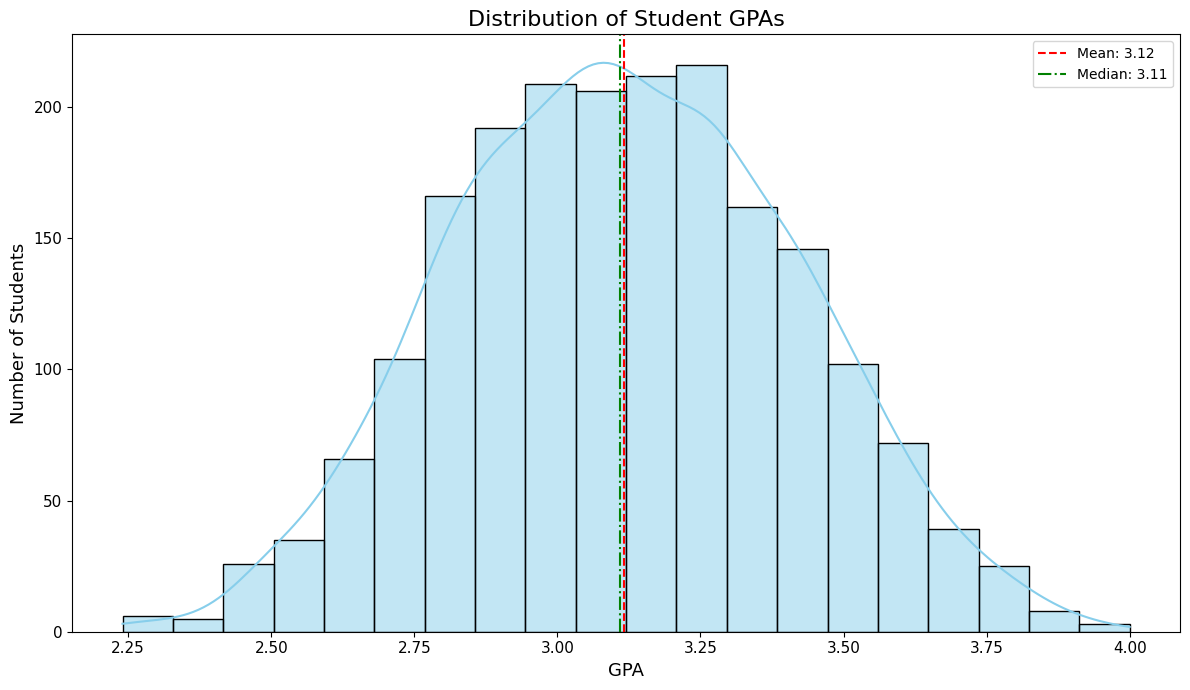

In [10]:
# Plot GPA histogram to show the distribution between students and save it as .jpg 
plt.figure(figsize=(12, 7))
sns.histplot(data=df_realnames_lifestyle, x="GPA", bins=20, kde=True, color="skyblue", edgecolor="black")
plt.axvline(df_realnames_lifestyle["GPA"].mean(), color='red', linestyle='--', label=f"Mean: {df_realnames_lifestyle['GPA'].mean():.2f}")
plt.axvline(df_realnames_lifestyle["GPA"].median(), color='green', linestyle='-.', label=f"Median: {df_realnames_lifestyle['GPA'].median():.2f}")
plt.title("Distribution of Student GPAs", fontsize=16)
plt.xlabel("GPA", fontsize=13)
plt.ylabel("Number of Students", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend()
plt.tight_layout()
plt.savefig("results/plots/histogram1.jpg", format='jpg')
plt.show()


In [ ]:
# Function to create a single correlation heatmap and save the image as .jpg
def plot_hours_vs_stress_heatmap(data, hours_col, title, filename, cmap='YlGnBu'):
    """
    This function creates a heatmap showing the relationship between a selected Hours_Per_Day column and Stress_Level, and saves it as a .jpg image.

    data: DataFrame – the source data
    hours_col: str – column for the y-axis (e.g., 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', etc.)
    title: str – title of the plot
    filename: str – name of the file to save as .jpg (e.g., "heatmap1.jpg")
    cmap: str – color map for the heatmap (default 'YlGnBu')

    Returns nothing, just saves the image and shows the plot.
    """
    corr_matrix = data[[hours_col, "Stress_Level_Numeric"]].corr()

    # Shorten axis labels for readability
    label_map = {hours_col: hours_col.replace("_Hours_Per_Day", "").replace("_", " "), "Stress_Level_Numeric": "Stress Level"}
    corr_matrix = corr_matrix.rename(index=label_map, columns=label_map)

    plt.figure(figsize=(12, 7))
    ax = sns.heatmap(
        corr_matrix,
        annot=True,
        fmt='.2f',
        cmap=cmap,
        vmin=-1,
        vmax=1,
        center=0,
        linewidths=0.5,
        linecolor='black',
        cbar_kws={'label': 'Correlation Coefficient'}
    )

    plt.title(title, fontsize=16)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    plt.tight_layout()
    plt.savefig(f"results/plots/{filename}", format='jpg')
    plt.show()


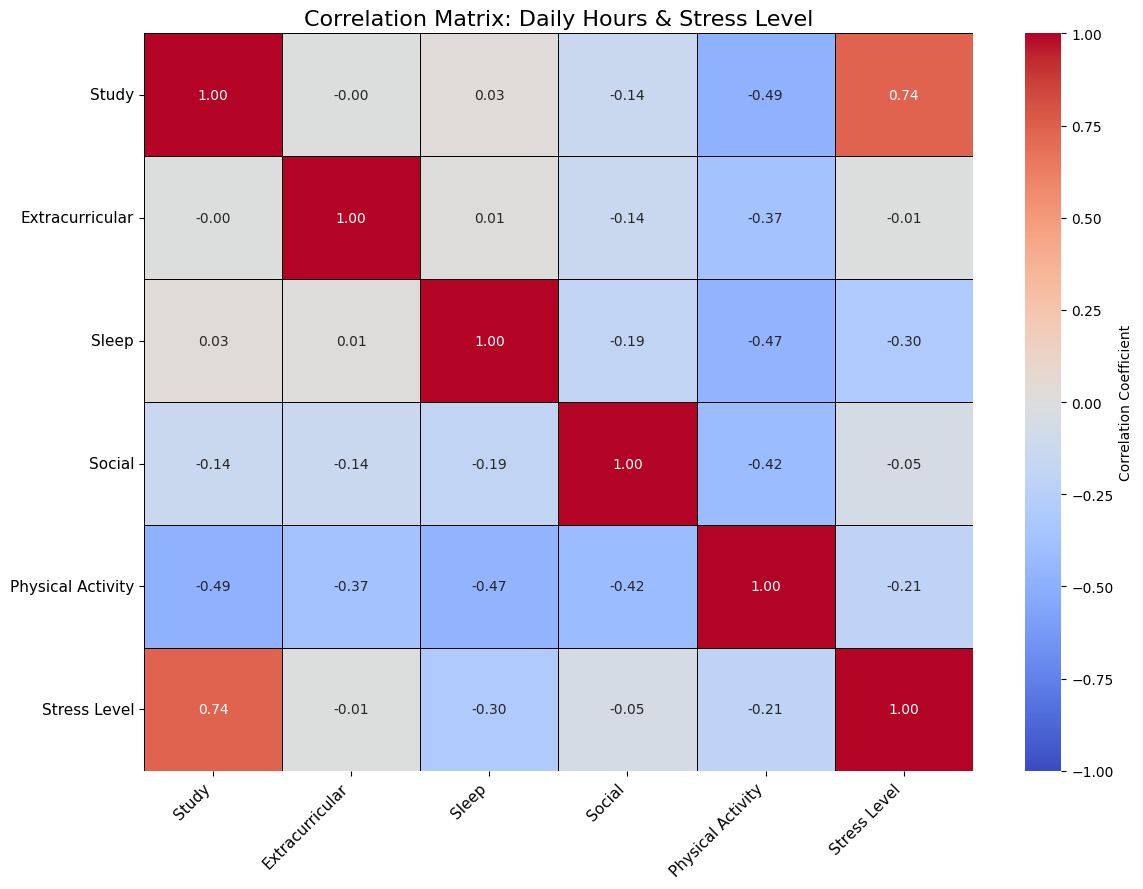

In [14]:
# Combined heatmap showing correlations between all Hours_Per_Day columns and Stress Level
cols_of_interest = hour_cols + ["Stress_Level_Numeric"]
corr_matrix = df_realnames_lifestyle[cols_of_interest].corr()

# Shorten axis labels for readability
label_map = {col: col.replace("_Hours_Per_Day", "").replace("_", " ") for col in hour_cols}
label_map["Stress_Level_Numeric"] = "Stress Level"
corr_matrix = corr_matrix.rename(index=label_map, columns=label_map)

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    linecolor="black",
    cbar_kws={"label": "Correlation Coefficient"},
)
plt.title("Correlation Matrix: Daily Hours & Stress Level", fontsize=16)
plt.xticks(fontsize=11, rotation=45, ha="right")
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.savefig("results/plots/heatmap_combined.jpg", format="jpg")
plt.show()